# 04 — Wind and Vector Analysis
## จากองค์ประกอบลม $u$ และ $v$ สู่ Wind Speed, Wind Direction และ Vertical Wind Structure

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 EVENT teaching dataset  
**บทก่อนหน้า:** Notebook 03 — Pressure-Level Atmospheric Structure

Notebook นี้ตอบคำถามหลักว่า:

```text
u และ v คืออะไร?
        ↓
ทำไม u หรือ v เพียงตัวเดียวไม่ใช่ wind speed?
        ↓
คำนวณ wind speed อย่างไร?
        ↓
meteorological wind direction ต่างจาก vector direction อย่างไร?
        ↓
แสดง wind vectors บนแผนที่อย่างไร?
        ↓
ทำไมต้องลดจำนวนลูกศรด้วย vector thinning?
        ↓
ลมที่ 850 / 500 / 200 hPa แตกต่างกันอย่างไร?
        ↓
vertical wind structure บอกอะไรเกี่ยวกับ atmosphere?
```

แนวคิดสำคัญ:

> **ลมเป็น vector quantity มีทั้ง magnitude และ direction**

และ:

> **การอ่าน circulation ต้องดูทั้ง $u$, $v$, wind speed และ spatial pattern ของ vectors**

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. อธิบายความหมายของ zonal wind component $u$
2. อธิบายความหมายของ meridional wind component $v$
3. อธิบาย sign convention ของ $u$ และ $v$
4. คำนวณ wind speed จาก $u$ และ $v$
5. คำนวณ meteorological wind direction
6. แยก wind vector direction กับ meteorological wind direction
7. สร้าง wind-speed map พร้อม quiver vectors
8. อธิบายเหตุผลของ vector thinning
9. เปรียบเทียบ circulation ที่ 850, 500 และ 200 hPa
10. สร้าง vertical wind profiles ที่ตำแหน่งตัวอย่าง
11. คำนวณ 850–200 hPa wind-vector difference
12. อธิบายว่าค่า vector difference ไม่ใช่ vertical-shear rate โดยตรง
13. export figures, point tables และ wind diagnostics

# 1. Wind เป็น Vector Quantity

ลมมีองค์ประกอบสองแกนในแนวราบ:

```text
u
→ zonal component
→ east–west direction

v
→ meridional component
→ north–south direction
```

ดังนั้น wind vector เขียนได้เป็น:

$$
\vec{V}
=
u\hat{i}
+
v\hat{j}
$$

# 2. Sign Convention ของ $u$ และ $v$

สำหรับ zonal wind:

```text
u > 0 → motion toward east → westerly wind
u < 0 → motion toward west → easterly wind
```

สำหรับ meridional wind:

```text
v > 0 → motion toward north → southerly wind
v < 0 → motion toward south → northerly wind
```

ชื่อ meteorological wind direction ระบุทิศที่ลม **พัดมา**

# 3. Wind Speed

Wind speed คือ magnitude ของ vector:

$$
V
=
\sqrt{
u^2
+
v^2
}
$$

ดังนั้น:

```text
u ≠ wind speed
v ≠ wind speed
```

# 4. Meteorological Wind Direction

Meteorological wind direction วัดตามเข็มนาฬิกาจากทิศเหนือ และระบุทิศที่ลมพัดมา

```text
0°   → northerly
90°  → easterly
180° → southerly
270° → westerly
```

จาก $u$ และ $v$:

$$
D
=
\left[
270^\circ
-
\operatorname{atan2}(v,u)
\frac{180^\circ}{\pi}
\right]
\bmod 360^\circ
$$

# 5. Quiver Plot และ Vector Thinning

`quiver()` ใช้ลูกศรเพื่อแสดง wind vectors

ถ้า plot ทุก grid cell แผนที่จะหนาแน่นเกินไป จึงใช้:

```python
skip = 4

u[::skip, ::skip]
v[::skip, ::skip]
```

การ thinning เปลี่ยนเฉพาะ density ของลูกศรที่แสดง

> **ไม่ได้เปลี่ยน atmospheric field ต้นฉบับ**

# 6. Vertical Wind Structure

```text
850 hPa
→ lower troposphere

500 hPa
→ mid-troposphere

200 hPa
→ upper troposphere
```

ดังนั้น circulation ต้องพิจารณาหลายระดับ ไม่ใช่ดูเพียงแผนที่เดียว

# 7. Wind-Vector Difference ระหว่างสองระดับ

$$
\Delta u
=
u_2-u_1
$$

$$
\Delta v
=
v_2-v_1
$$

และ:

$$
\left|\Delta\vec{V}\right|
=
\sqrt{
(\Delta u)^2
+
(\Delta v)^2
}
$$

บทนี้ใช้ 850–200 hPa

แต่ต้องเรียกว่า **wind-vector difference** ไม่ใช่ vertical-shear rate เพราะยังไม่ได้หารด้วย geometric depth

# 8. Vertical Wind Shear เชิงอนุพันธ์

แนวคิดเชิงกายภาพของ vertical wind shear เช่น:

$$
\frac{\partial u}{\partial z}
$$

และ:

$$
\frac{\partial v}{\partial z}
$$

หรือประมาณ:

$$
S
=
\frac{
\left|\vec{V}_2-\vec{V}_1\right|
}{
z_2-z_1
}
$$

pressure difference ไม่ใช่ geometric-height difference คงที่

# 9. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "cartopy>=0.23",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *PACKAGES,
    ]
)

print("Libraries ready.")

Libraries ready.


# 10. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

print(
    "Google Drive mounted:",
    DRIVE_ROOT,
)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 11. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Xarray:", xr.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0


# 12. Course paths

In [4]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / "00_source_github"
)

METADATA_DIR = (
    COURSE_ROOT
    / "02_metadata"
)

OUTPUT_DIR = (
    COURSE_ROOT
    / "03_output"
)

FIGURE_DIR = (
    COURSE_ROOT
    / "04_figures"
    / "04"
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

EVENT_FILE = (
    SOURCE_GITHUB_DIR
    / "era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc"
)

if not EVENT_FILE.exists():
    raise FileNotFoundError(
        "EVENT teaching dataset not found. "
        "Run Notebook 00 first."
    )

print(
    "EVENT file:",
    EVENT_FILE,
)

EVENT file: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_noul_20111002_05_SEAsia_pressure_levels_0.5deg.nc


# 13. เปิด EVENT dataset

In [5]:
# CELL 5 — Open EVENT dataset

ds = xr.open_dataset(
    EVENT_FILE,
    decode_times=True,
)

print(ds)

<xarray.Dataset> Size: 14MB
Dimensions:    (time: 4, level: 8, latitude: 100, longitude: 140)
Coordinates:
  * time       (time) datetime64[ns] 32B 2011-10-02 2011-10-03 ... 2011-10-05
  * level      (level) int32 32B 200 250 300 500 700 850 925 1000
  * latitude   (latitude) float32 400B 44.88 44.38 43.88 ... -4.125 -4.625
  * longitude  (longitude) float32 560B 60.12 60.62 61.12 ... 128.6 129.1 129.6
Data variables:
    d          (time, level, latitude, longitude) float32 2MB ...
    z          (time, level, latitude, longitude) float32 2MB ...
    r          (time, level, latitude, longitude) float32 2MB ...
    q          (time, level, latitude, longitude) float32 2MB ...
    t          (time, level, latitude, longitude) float32 2MB ...
    u          (time, level, latitude, longitude) float32 2MB ...
    v          (time, level, latitude, longitude) float32 2MB ...
    vo         (time, level, latitude, longitude) float32 2MB ...
Attributes: (12/17)
    Conventions:              

# 14. ตรวจ Wind Variables และ Pressure Levels

In [6]:
# CELL 6 — Wind-field audit

required_variables = {
    "u",
    "v",
}

missing_variables = (
    required_variables
    - set(
        ds.data_vars
    )
)

if missing_variables:
    raise KeyError(
        f"Missing wind variables: {missing_variables}"
    )

PRESSURE_LEVELS = np.asarray(
    ds["level"].values,
    dtype=float,
)

WIND_AUDIT = pd.DataFrame(
    [
        {
            "variable": "u",
            "long_name": ds["u"].attrs.get(
                "long_name",
                "",
            ),
            "units": ds["u"].attrs.get(
                "units",
                "",
            ),
            "dimensions": ",".join(
                ds["u"].dims
            ),
        },
        {
            "variable": "v",
            "long_name": ds["v"].attrs.get(
                "long_name",
                "",
            ),
            "units": ds["v"].attrs.get(
                "units",
                "",
            ),
            "dimensions": ",".join(
                ds["v"].dims
            ),
        },
    ]
)

display(
    WIND_AUDIT
)

print(
    "Pressure levels:",
    PRESSURE_LEVELS,
)

,variable,long_name,units,dimensions
0,u,U component of wind,m s**-1,"time,level,latitude,longitude"
1,v,V component of wind,m s**-1,"time,level,latitude,longitude"


Pressure levels: [ 200.  250.  300.  500.  700.  850.  925. 1000.]


# 15. กำหนดเวลาและ Analysis Domain

In [7]:
# CELL 7 — Analysis settings

REFERENCE_TIME = pd.Timestamp(
    "2011-10-02 00:00:00"
)

ANALYSIS_DOMAIN = {
    "lon_min": 80.0,
    "lon_max": 130.0,
    "lat_min": 0.0,
    "lat_max": 35.0,
}

VECTOR_SKIP = 4

available_times = pd.DatetimeIndex(
    pd.to_datetime(
        ds["time"].values
    )
)

if REFERENCE_TIME not in available_times:
    raise ValueError(
        "Reference time not found."
    )

print(
    "Reference time:",
    REFERENCE_TIME,
)

print(
    "Vector thinning step:",
    VECTOR_SKIP,
)

Reference time: 2011-10-02 00:00:00
Vector thinning step: 4


# 16. Spatial Helper Functions

In [8]:
# CELL 8 — Coordinate-aware spatial subset

def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values[-1] > values[0]:
        return slice(
            lower,
            upper,
        )

    return slice(
        upper,
        lower,
    )


def subset_domain(
    data_array,
    domain,
):
    return data_array.sel(
        latitude=coordinate_slice(
            data_array["latitude"],
            domain["lat_min"],
            domain["lat_max"],
        ),
        longitude=coordinate_slice(
            data_array["longitude"],
            domain["lon_min"],
            domain["lon_max"],
        ),
    )

In [9]:
# CELL 9 — Base map helper

def decorate_map(
    ax,
    *,
    domain,
):
    ax.coastlines(
        resolution="110m",
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        [
            domain["lon_min"],
            domain["lon_max"],
            domain["lat_min"],
            domain["lat_max"],
        ],
        crs=ccrs.PlateCarree(),
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.35,
        alpha=0.45,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False

    return ax

# 17. Wind Diagnostic Functions

In [10]:
# CELL 10 — Wind diagnostic functions

def wind_speed(
    u,
    v,
):
    speed = np.hypot(
        u,
        v,
    )

    speed.name = (
        "wind_speed"
    )

    speed.attrs.update(
        {
            "long_name": "Wind speed",
            "units": "m s-1",
        }
    )

    return speed


def meteorological_wind_direction(
    u,
    v,
):
    direction = (
        270.0
        - np.degrees(
            np.arctan2(
                v,
                u,
            )
        )
    ) % 360.0

    direction.name = (
        "wind_direction"
    )

    direction.attrs.update(
        {
            "long_name": (
                "Meteorological wind direction"
            ),
            "units": "degree",
            "definition": (
                "Direction from which the wind blows, clockwise from north"
            ),
        }
    )

    return direction

# 18. สร้าง Wind Fields ที่ 850, 500 และ 200 hPa

In [11]:
# CELL 11 — Prepare multi-level wind fields

event = ds.sel(
    time=REFERENCE_TIME
)

WIND_LEVELS = [
    850,
    500,
    200,
]

WIND_FIELDS = {}

for level in WIND_LEVELS:
    u_field = subset_domain(
        event["u"].sel(
            level=level
        ),
        ANALYSIS_DOMAIN,
    )

    v_field = subset_domain(
        event["v"].sel(
            level=level
        ),
        ANALYSIS_DOMAIN,
    )

    speed_field = wind_speed(
        u_field,
        v_field,
    )

    direction_field = (
        meteorological_wind_direction(
            u_field,
            v_field,
        )
    )

    WIND_FIELDS[level] = {
        "u": u_field,
        "v": v_field,
        "speed": speed_field,
        "direction": direction_field,
    }

print(
    "Wind fields ready:",
    list(
        WIND_FIELDS.keys()
    ),
)

Wind fields ready: [850, 500, 200]


# 19. Figure 04-1 — 850-hPa Wind Speed and Vectors

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


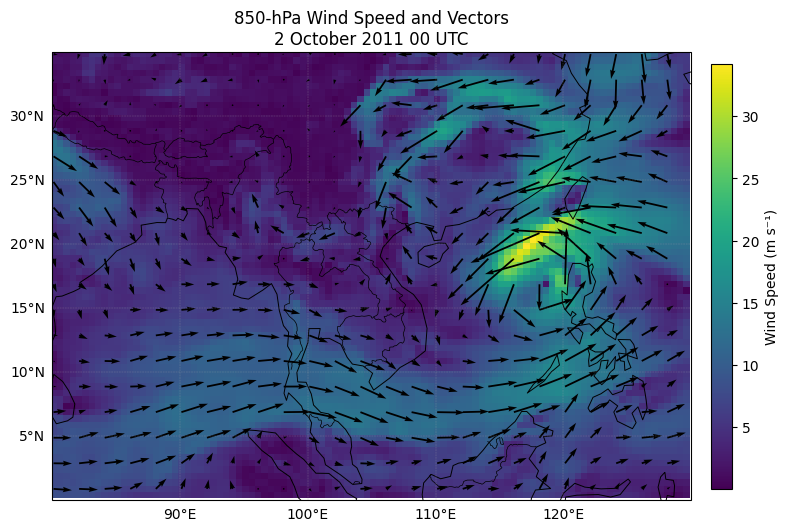

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/04/04_01_850hPa_wind_speed_vectors.png


In [12]:
# CELL 12 — 850-hPa wind map

level = 850

u_field = WIND_FIELDS[level]["u"]
v_field = WIND_FIELDS[level]["v"]
speed_field = WIND_FIELDS[level]["speed"]

fig = plt.figure(
    figsize=(10, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    speed_field["longitude"],
    speed_field["latitude"],
    speed_field,
    transform=ccrs.PlateCarree(),
    shading="auto",
)

skip = VECTOR_SKIP

ax.quiver(
    u_field["longitude"].values[::skip],
    u_field["latitude"].values[::skip],
    u_field.values[::skip, ::skip],
    v_field.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    domain=ANALYSIS_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Wind Speed (m s⁻¹)"
)

ax.set_title(
    "850-hPa Wind Speed and Vectors\n"
    "2 October 2011 00 UTC"
)

FIG_04_01 = (
    FIGURE_DIR
    / "04_01_850hPa_wind_speed_vectors.png"
)

plt.savefig(
    FIG_04_01,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_04_01,
)

# 20. อ่าน Figure 04-1 อย่างไร?

ให้แยกการอ่าน:

```text
shading
→ wind-speed magnitude

arrows
→ vector direction and relative magnitude
```

จากนั้นจึงพิจารณา low-level circulation และบริเวณที่ลมแรงกว่า/อ่อนกว่า

Notebook 04 ยังไม่ใช้ visual convergence เป็นหลักฐานของ divergence เชิงปริมาณ

# 21. Figure 04-2 — 500-hPa Wind Speed and Vectors

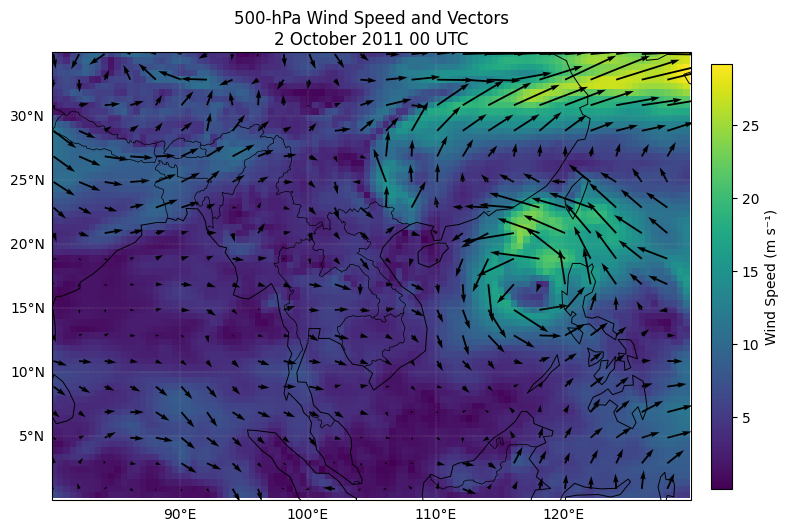

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/04/04_02_500hPa_wind_speed_vectors.png


In [13]:
# CELL 13 — 500-hPa wind map

level = 500

u_field = WIND_FIELDS[level]["u"]
v_field = WIND_FIELDS[level]["v"]
speed_field = WIND_FIELDS[level]["speed"]

fig = plt.figure(
    figsize=(10, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    speed_field["longitude"],
    speed_field["latitude"],
    speed_field,
    transform=ccrs.PlateCarree(),
    shading="auto",
)

skip = VECTOR_SKIP

ax.quiver(
    u_field["longitude"].values[::skip],
    u_field["latitude"].values[::skip],
    u_field.values[::skip, ::skip],
    v_field.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    domain=ANALYSIS_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Wind Speed (m s⁻¹)"
)

ax.set_title(
    "500-hPa Wind Speed and Vectors\n"
    "2 October 2011 00 UTC"
)

FIG_04_02 = (
    FIGURE_DIR
    / "04_02_500hPa_wind_speed_vectors.png"
)

plt.savefig(
    FIG_04_02,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_04_02,
)

# 22. Figure 04-3 — 200-hPa Wind Speed and Vectors

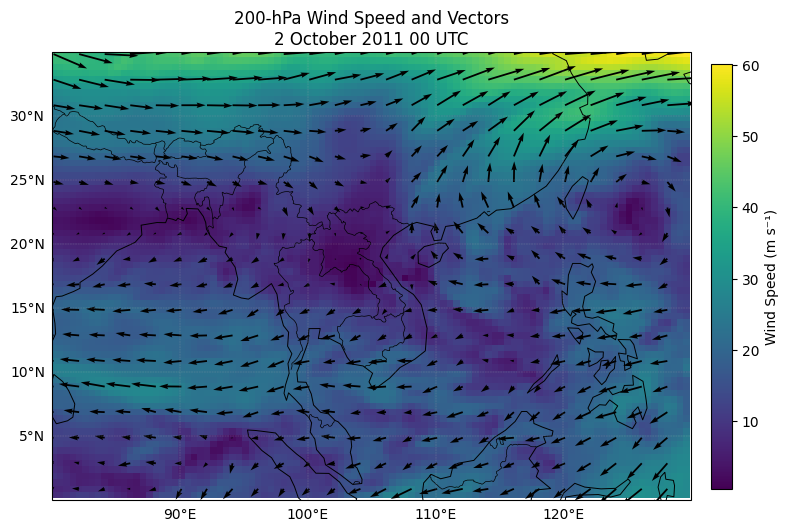

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/04/04_03_200hPa_wind_speed_vectors.png


In [14]:
# CELL 14 — 200-hPa wind map

level = 200

u_field = WIND_FIELDS[level]["u"]
v_field = WIND_FIELDS[level]["v"]
speed_field = WIND_FIELDS[level]["speed"]

fig = plt.figure(
    figsize=(10, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    speed_field["longitude"],
    speed_field["latitude"],
    speed_field,
    transform=ccrs.PlateCarree(),
    shading="auto",
)

skip = VECTOR_SKIP

ax.quiver(
    u_field["longitude"].values[::skip],
    u_field["latitude"].values[::skip],
    u_field.values[::skip, ::skip],
    v_field.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    domain=ANALYSIS_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Wind Speed (m s⁻¹)"
)

ax.set_title(
    "200-hPa Wind Speed and Vectors\n"
    "2 October 2011 00 UTC"
)

FIG_04_03 = (
    FIGURE_DIR
    / "04_03_200hPa_wind_speed_vectors.png"
)

plt.savefig(
    FIG_04_03,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_04_03,
)

# 23. Figure 04-4 — Three-Level Wind Comparison

Figure นี้ใช้ common wind-speed scale เพื่อให้เปรียบเทียบ magnitude ระหว่างระดับได้โดยตรง

```text
same color value
→ same wind speed
```

ข้อควรระวัง:

> ถ้า upper-level wind เร็วกว่ามาก low-level variations อาจดูมี contrast น้อยลง

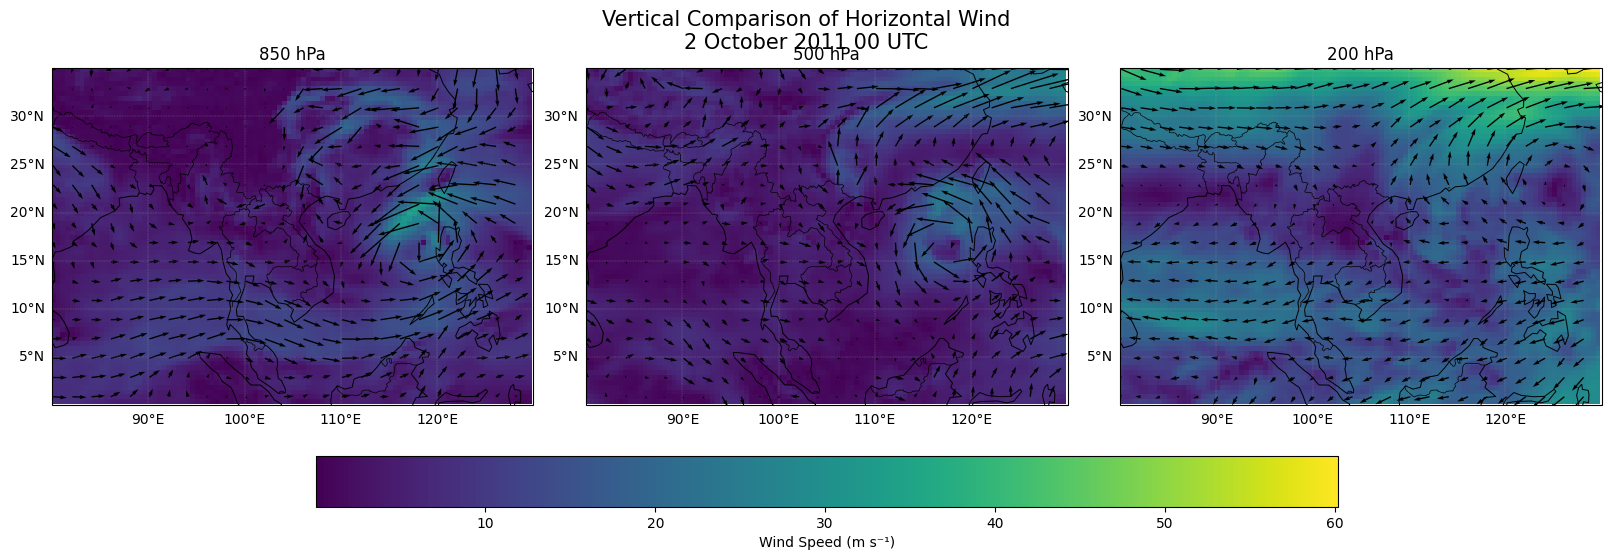

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/04/04_04_three_level_wind_comparison.png


In [15]:
# CELL 15 — Three-level wind comparison

all_speed_fields = [
    WIND_FIELDS[level]["speed"]
    for level in WIND_LEVELS
]

common_vmin = float(
    min(
        field.min()
        for field in all_speed_fields
    )
)

common_vmax = float(
    max(
        field.max()
        for field in all_speed_fields
    )
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(16, 5.5),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

for ax, level in zip(
    axes,
    WIND_LEVELS,
):
    u_field = WIND_FIELDS[level]["u"]
    v_field = WIND_FIELDS[level]["v"]
    speed_field = WIND_FIELDS[level]["speed"]

    mesh = ax.pcolormesh(
        speed_field["longitude"],
        speed_field["latitude"],
        speed_field,
        transform=ccrs.PlateCarree(),
        shading="auto",
        vmin=common_vmin,
        vmax=common_vmax,
    )

    skip = VECTOR_SKIP

    ax.quiver(
        u_field["longitude"].values[::skip],
        u_field["latitude"].values[::skip],
        u_field.values[::skip, ::skip],
        v_field.values[::skip, ::skip],
        transform=ccrs.PlateCarree(),
    )

    decorate_map(
        ax,
        domain=ANALYSIS_DOMAIN,
    )

    ax.set_title(
        f"{level} hPa"
    )

cbar = fig.colorbar(
    mesh,
    ax=axes.tolist(),
    orientation="horizontal",
    pad=0.08,
    shrink=0.85,
)

cbar.set_label(
    "Wind Speed (m s⁻¹)"
)

fig.suptitle(
    "Vertical Comparison of Horizontal Wind\n"
    "2 October 2011 00 UTC",
    fontsize=15,
)

FIG_04_04 = (
    FIGURE_DIR
    / "04_04_three_level_wind_comparison.png"
)

plt.savefig(
    FIG_04_04,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_04_04,
)

# 24. Regional Wind-Speed Statistics

In [16]:
# CELL 16 — Regional wind statistics

wind_stats_rows = []

for level in WIND_LEVELS:
    speed_field = (
        WIND_FIELDS[level]["speed"]
    )

    wind_stats_rows.append(
        {
            "pressure_hPa": level,
            "minimum_speed_ms": float(
                speed_field.min()
            ),
            "mean_speed_ms": float(
                speed_field.mean()
            ),
            "median_speed_ms": float(
                speed_field.median()
            ),
            "maximum_speed_ms": float(
                speed_field.max()
            ),
        }
    )

WIND_SPEED_STATS = pd.DataFrame(
    wind_stats_rows
)

display(
    WIND_SPEED_STATS
)

,pressure_hPa,minimum_speed_ms,mean_speed_ms,median_speed_ms,maximum_speed_ms
0,850,0.019079,7.306516,6.579138,34.245907
1,500,0.059542,6.814671,5.420532,29.184069
2,200,0.470465,18.620277,17.196907,60.177284


# 25. ตำแหน่งตัวอย่างสำหรับ Vertical Wind Profiles

In [17]:
# CELL 17 — Example locations

LOCATIONS = {
    "Bangkok": {
        "latitude": 13.7563,
        "longitude": 100.5018,
    },
    "Chiang Mai": {
        "latitude": 18.7883,
        "longitude": 98.9853,
    },
    "Nakhon Ratchasima": {
        "latitude": 14.9799,
        "longitude": 102.0977,
    },
}

display(
    pd.DataFrame(
        [
            {
                "location": name,
                **coords,
            }
            for name, coords
            in LOCATIONS.items()
        ]
    )
)

,location,latitude,longitude
0,Bangkok,13.7563,100.5018
1,Chiang Mai,18.7883,98.9853
2,Nakhon Ratchasima,14.9799,102.0977


# 26. สกัด $u$, $v$, Wind Speed และ Wind Direction ทุก Pressure Level

In [18]:
# CELL 18 — Point vertical wind profiles

point_wind_rows = []

for location_name, coords in LOCATIONS.items():
    u_profile = (
        event["u"]
        .sel(
            latitude=coords["latitude"],
            longitude=coords["longitude"],
            method="nearest",
        )
    )

    v_profile = (
        event["v"]
        .sel(
            latitude=coords["latitude"],
            longitude=coords["longitude"],
            method="nearest",
        )
    )

    speed_profile = wind_speed(
        u_profile,
        v_profile,
    )

    direction_profile = (
        meteorological_wind_direction(
            u_profile,
            v_profile,
        )
    )

    for index, level in enumerate(
        u_profile["level"].values
    ):
        point_wind_rows.append(
            {
                "location": location_name,
                "pressure_hPa": float(
                    level
                ),
                "u_ms": float(
                    u_profile.isel(
                        level=index
                    )
                ),
                "v_ms": float(
                    v_profile.isel(
                        level=index
                    )
                ),
                "wind_speed_ms": float(
                    speed_profile.isel(
                        level=index
                    )
                ),
                "wind_direction_deg": float(
                    direction_profile.isel(
                        level=index
                    )
                ),
                "selected_grid_latitude": float(
                    u_profile["latitude"]
                ),
                "selected_grid_longitude": float(
                    u_profile["longitude"]
                ),
            }
        )

POINT_WIND_PROFILES = pd.DataFrame(
    point_wind_rows
)

display(
    POINT_WIND_PROFILES.head(
        12
    )
)

,location,pressure_hPa,u_ms,v_ms,wind_speed_ms,wind_direction_deg,selected_grid_latitude,selected_grid_longitude
0,Bangkok,200.0,-13.812380,-5.435791,14.843506,68.518127,13.875,100.625
1,Bangkok,250.0,-11.573760,-4.037338,12.257733,70.769409,13.875,100.625
2,Bangkok,300.0,-6.546968,-2.567729,7.032497,68.584839,13.875,100.625
3,Bangkok,500.0,4.721021,-0.616281,4.761075,277.437317,13.875,100.625
4,Bangkok,700.0,4.243125,-2.803606,5.085697,303.454376,13.875,100.625
5,Bangkok,850.0,7.872868,-3.157141,8.482310,291.851532,13.875,100.625
6,Bangkok,925.0,9.457951,-1.585562,9.589934,279.516754,13.875,100.625
7,Bangkok,1000.0,3.270632,1.744730,3.706902,241.922150,13.875,100.625
8,Chiang Mai,200.0,-2.904834,-6.106444,6.762154,25.440399,18.875,99.125
9,Chiang Mai,250.0,-0.414605,-6.914925,6.927343,3.431213,18.875,99.125


# 27. Figure 04-5 — Vertical Profiles of $u$, $v$ and Wind Speed

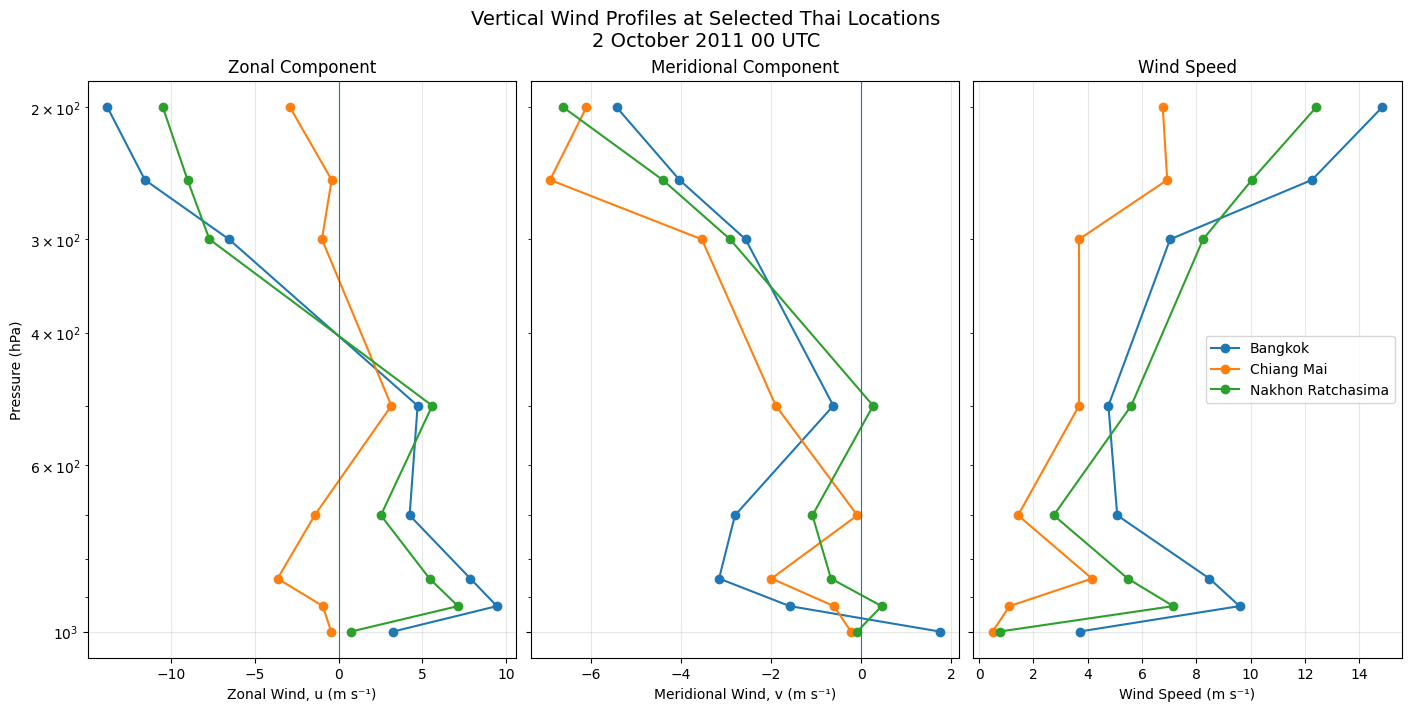

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/04/04_05_vertical_wind_profiles.png


In [19]:
# CELL 19 — Vertical wind-component profiles

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(14, 7),
    sharey=True,
    constrained_layout=True,
)

for location_name, group in (
    POINT_WIND_PROFILES.groupby(
        "location"
    )
):
    group = group.sort_values(
        "pressure_hPa",
        ascending=False,
    )

    axes[0].plot(
        group["u_ms"],
        group["pressure_hPa"],
        marker="o",
        label=location_name,
    )

    axes[1].plot(
        group["v_ms"],
        group["pressure_hPa"],
        marker="o",
        label=location_name,
    )

    axes[2].plot(
        group["wind_speed_ms"],
        group["pressure_hPa"],
        marker="o",
        label=location_name,
    )

for ax in axes:
    ax.set_yscale(
        "log"
    )
    ax.invert_yaxis()
    ax.grid(
        True,
        alpha=0.3,
    )

axes[0].axvline(
    0,
    linewidth=0.8,
)

axes[1].axvline(
    0,
    linewidth=0.8,
)

axes[0].set_xlabel(
    "Zonal Wind, u (m s⁻¹)"
)

axes[0].set_ylabel(
    "Pressure (hPa)"
)

axes[0].set_title(
    "Zonal Component"
)

axes[1].set_xlabel(
    "Meridional Wind, v (m s⁻¹)"
)

axes[1].set_title(
    "Meridional Component"
)

axes[2].set_xlabel(
    "Wind Speed (m s⁻¹)"
)

axes[2].set_title(
    "Wind Speed"
)

axes[2].legend(
    loc="best"
)

fig.suptitle(
    "Vertical Wind Profiles at Selected Thai Locations\n"
    "2 October 2011 00 UTC",
    fontsize=14,
)

FIG_04_05 = (
    FIGURE_DIR
    / "04_05_vertical_wind_profiles.png"
)

plt.savefig(
    FIG_04_05,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_04_05,
)

# 28. การอ่าน Vertical Wind Profile

ให้สังเกต:

```text
u sign
→ eastward / westward motion

v sign
→ northward / southward motion

wind speed
→ magnitude
```

ถ้า $u$ หรือ $v$ เปลี่ยน sign ตามระดับ แสดงว่า wind component เปลี่ยน direction ตาม vertical coordinate

# 29. 850–200 hPa Wind-Vector Difference

In [20]:
# CELL 20 — 850–200 hPa wind-vector difference

u_850 = WIND_FIELDS[850]["u"]
v_850 = WIND_FIELDS[850]["v"]

u_200 = WIND_FIELDS[200]["u"]
v_200 = WIND_FIELDS[200]["v"]

delta_u_850_200 = (
    u_200
    - u_850
)

delta_v_850_200 = (
    v_200
    - v_850
)

delta_speed_850_200 = np.hypot(
    delta_u_850_200,
    delta_v_850_200,
)

delta_speed_850_200.name = (
    "wind_vector_difference_850_200"
)

delta_speed_850_200.attrs.update(
    {
        "long_name": (
            "850–200 hPa wind-vector difference magnitude"
        ),
        "units": "m s-1",
    }
)

print(
    delta_speed_850_200
)

<xarray.DataArray 'wind_vector_difference_850_200' (latitude: 70, longitude: 100)> Size: 28kB
array([[39.86955 , 40.29357 , 40.057007, ..., 59.75503 , 59.703568,
        59.56905 ],
       [39.022385, 39.42602 , 40.041565, ..., 55.513912, 55.555218,
        55.85045 ],
       [37.816517, 38.219913, 38.70762 , ..., 51.67031 , 52.096867,
        52.65096 ],
       ...,
       [14.884788, 14.954465, 14.908045, ..., 31.150068, 31.580256,
        31.168505],
       [14.354919, 14.688748, 15.377577, ..., 30.858994, 30.438274,
        30.34505 ],
       [16.16686 , 16.502415, 17.230871, ..., 30.12046 , 30.10144 ,
        30.261915]], dtype=float32)
Coordinates:
  * latitude   (latitude) float32 280B 34.88 34.38 33.88 ... 1.375 0.875 0.375
  * longitude  (longitude) float32 400B 80.12 80.62 81.12 ... 128.6 129.1 129.6
    time       datetime64[ns] 8B 2011-10-02
Attributes:
    units:          m s-1
    long_name:      850–200 hPa wind-vector difference magnitude
    standard_name:  eastward_wi

# 30. Figure 04-6 — 850–200 hPa Wind-Vector Difference

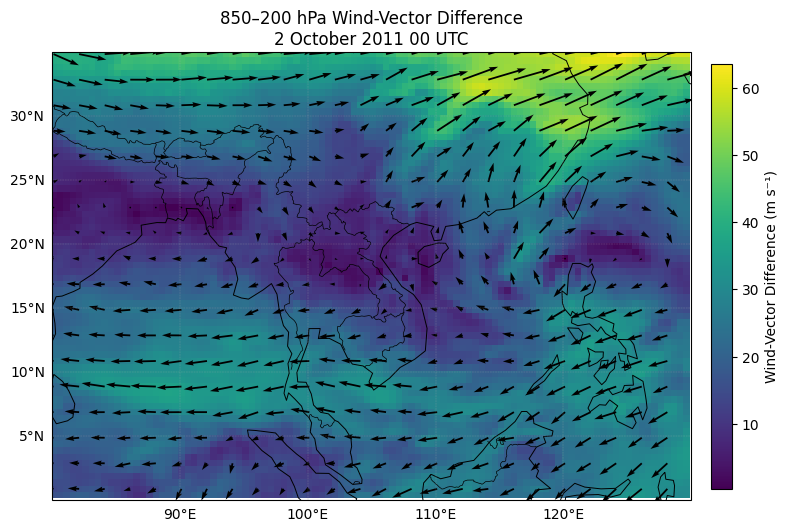

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/04/04_06_850_200hPa_wind_vector_difference.png


In [21]:
# CELL 21 — Wind-vector difference map

fig = plt.figure(
    figsize=(10, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    delta_speed_850_200["longitude"],
    delta_speed_850_200["latitude"],
    delta_speed_850_200,
    transform=ccrs.PlateCarree(),
    shading="auto",
)

skip = VECTOR_SKIP

ax.quiver(
    delta_u_850_200["longitude"].values[::skip],
    delta_u_850_200["latitude"].values[::skip],
    delta_u_850_200.values[::skip, ::skip],
    delta_v_850_200.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    domain=ANALYSIS_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Wind-Vector Difference (m s⁻¹)"
)

ax.set_title(
    "850–200 hPa Wind-Vector Difference\n"
    "2 October 2011 00 UTC"
)

FIG_04_06 = (
    FIGURE_DIR
    / "04_06_850_200hPa_wind_vector_difference.png"
)

plt.savefig(
    FIG_04_06,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_04_06,
)

# 31. สิ่งที่ Figure 04-6 บอกได้และบอกไม่ได้

บอกได้:

```text
upper-level wind vector
ต่างจาก
lower-level wind vector
มากน้อยเพียงใด
```

บอกไม่ได้โดยตรง:

```text
vertical shear rate in s⁻¹
```

เพราะยังไม่ได้หารด้วย geometric depth

ดังนั้น figure นี้ควรเรียกว่า:

> **850–200 hPa wind-vector difference**

# 32. Wind Direction Table at Selected Locations

In [22]:
# CELL 22 — Selected-level wind-direction table

SELECTED_DIRECTION_LEVELS = [
    850,
    500,
    200,
]

DIRECTION_TABLE = (
    POINT_WIND_PROFILES[
        POINT_WIND_PROFILES[
            "pressure_hPa"
        ].isin(
            SELECTED_DIRECTION_LEVELS
        )
    ]
    .copy()
    .sort_values(
        [
            "location",
            "pressure_hPa",
        ],
        ascending=[
            True,
            False,
        ],
    )
)

display(
    DIRECTION_TABLE[
        [
            "location",
            "pressure_hPa",
            "u_ms",
            "v_ms",
            "wind_speed_ms",
            "wind_direction_deg",
        ]
    ]
)

,location,pressure_hPa,u_ms,v_ms,wind_speed_ms,wind_direction_deg
5,Bangkok,850.0,7.872868,-3.157141,8.482310,291.851532
3,Bangkok,500.0,4.721021,-0.616281,4.761075,277.437317
0,Bangkok,200.0,-13.812380,-5.435791,14.843506,68.518127
13,Chiang Mai,850.0,-3.646191,-1.991763,4.154736,61.354034
11,Chiang Mai,500.0,3.152640,-1.895956,3.678829,301.022156
8,Chiang Mai,200.0,-2.904834,-6.106444,6.762154,25.440399
21,Nakhon Ratchasima,850.0,5.432745,-0.669507,5.473844,277.025452
19,Nakhon Ratchasima,500.0,5.595456,0.267838,5.601863,267.259521
16,Nakhon Ratchasima,200.0,-10.499977,-6.623581,12.414562,57.755493


# 33. Export Wind Diagnostics

In [23]:
# CELL 23 — Export tables

WIND_SPEED_STATS_CSV = (
    OUTPUT_DIR
    / "04_regional_wind_speed_statistics.csv"
)

POINT_WIND_PROFILES_CSV = (
    OUTPUT_DIR
    / "04_selected_location_vertical_wind_profiles.csv"
)

DIRECTION_TABLE_CSV = (
    OUTPUT_DIR
    / "04_selected_level_wind_direction.csv"
)

WIND_METADATA_CSV = (
    METADATA_DIR
    / "04_wind_analysis_metadata.csv"
)

WIND_SPEED_STATS.to_csv(
    WIND_SPEED_STATS_CSV,
    index=False,
)

POINT_WIND_PROFILES.to_csv(
    POINT_WIND_PROFILES_CSV,
    index=False,
)

DIRECTION_TABLE.to_csv(
    DIRECTION_TABLE_CSV,
    index=False,
)

WIND_METADATA = pd.DataFrame(
    [
        {
            "parameter": "reference_time_UTC",
            "value": str(
                REFERENCE_TIME
            ),
        },
        {
            "parameter": "analysis_domain",
            "value": str(
                ANALYSIS_DOMAIN
            ),
        },
        {
            "parameter": "vector_skip",
            "value": VECTOR_SKIP,
        },
        {
            "parameter": "wind_speed_formula",
            "value": "sqrt(u^2 + v^2)",
        },
        {
            "parameter": "wind_direction_definition",
            "value": (
                "Meteorological direction from which wind blows"
            ),
        },
        {
            "parameter": "wind_vector_difference_levels",
            "value": "850–200 hPa",
        },
        {
            "parameter": "wind_vector_difference_warning",
            "value": (
                "Not a vertical-shear rate because geometric depth is not applied"
            ),
        },
    ]
)

WIND_METADATA.to_csv(
    WIND_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    WIND_SPEED_STATS_CSV,
)

print(
    "Saved:",
    POINT_WIND_PROFILES_CSV,
)

print(
    "Saved:",
    DIRECTION_TABLE_CSV,
)

print(
    "Saved:",
    WIND_METADATA_CSV,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/04_regional_wind_speed_statistics.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/04_selected_location_vertical_wind_profiles.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/04_selected_level_wind_direction.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/04_wind_analysis_metadata.csv


# 34. Figure Manifest

In [24]:
# CELL 24 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            "figure": "04-01",
            "file": str(
                FIG_04_01
            ),
            "description": (
                "850-hPa wind speed and vectors"
            ),
        },
        {
            "figure": "04-02",
            "file": str(
                FIG_04_02
            ),
            "description": (
                "500-hPa wind speed and vectors"
            ),
        },
        {
            "figure": "04-03",
            "file": str(
                FIG_04_03
            ),
            "description": (
                "200-hPa wind speed and vectors"
            ),
        },
        {
            "figure": "04-04",
            "file": str(
                FIG_04_04
            ),
            "description": (
                "Three-level wind comparison"
            ),
        },
        {
            "figure": "04-05",
            "file": str(
                FIG_04_05
            ),
            "description": (
                "Vertical profiles of u, v and wind speed"
            ),
        },
        {
            "figure": "04-06",
            "file": str(
                FIG_04_06
            ),
            "description": (
                "850–200 hPa wind-vector difference"
            ),
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / "04_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

,figure,file,description
0,04-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,850-hPa wind speed and vectors
1,04-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,500-hPa wind speed and vectors
2,04-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,200-hPa wind speed and vectors
3,04-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Three-level wind comparison
4,04-05,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,"Vertical profiles of u, v and wind speed"
5,04-06,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,850–200 hPa wind-vector difference


# 35. Common Mistakes

### Mistake 1
คิดว่า:

```text
u = wind speed
```

### Mistake 2
คิดว่า positive $u$ หมายถึงลมมาจากทิศตะวันออก

จริง ๆ positive $u$ คือ motion toward east หรือ westerly wind

### Mistake 3
อ่าน quiver arrow direction เป็น meteorological direction โดยตรง

### Mistake 4
plot ลูกศรทุก grid cell จนอ่านแผนที่ไม่ได้

### Mistake 5
เรียก 850–200 hPa vector difference ว่า shear rate ทั้งที่ไม่ได้หารด้วย vertical depth

### Mistake 6
เปรียบเทียบหลาย pressure levels ด้วย color scale ต่างกันโดยไม่บอก

# 36. Exercises

### Exercise 1 — Wind Speed

เลือก grid point หนึ่งแล้วคำนวณ:

$$
V
=
\sqrt{u^2+v^2}
$$

### Exercise 2 — Wind Direction

ใช้ $u$ และ $v$ ที่ 850 hPa แล้วคำนวณ meteorological wind direction

### Exercise 3 — Vector Thinning

ทดลอง:

```text
VECTOR_SKIP = 2
VECTOR_SKIP = 4
VECTOR_SKIP = 8
```

### Exercise 4 — Vertical Comparison

เปรียบเทียบ 850, 500 และ 200 hPa ที่จังหวัดหนึ่ง

### Exercise 5 — Wind-Vector Difference

คำนวณ 850–200 hPa vector difference ที่ location หนึ่ง

### Exercise 6 — Interpretation

อธิบาย:

```text
wind speed
≠
u
≠
v
≠
wind direction
```

# 37. Final Readiness Check

In [25]:
# CELL 25 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": item,
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": note,
        }
    )


required_levels = {
    850,
    500,
    200,
}

available_levels = set(
    int(
        value
    )
    for value in np.atleast_1d(
        ds["level"].values
    )
)

add_check(
    "EVENT dataset opened",
    isinstance(
        ds,
        xr.Dataset,
    ),
)

add_check(
    "u wind component available",
    "u" in ds.data_vars,
)

add_check(
    "v wind component available",
    "v" in ds.data_vars,
)

add_check(
    "Required wind levels available",
    required_levels.issubset(
        available_levels
    ),
)

for figure_path, label in [
    (
        FIG_04_01,
        "850-hPa wind figure",
    ),
    (
        FIG_04_02,
        "500-hPa wind figure",
    ),
    (
        FIG_04_03,
        "200-hPa wind figure",
    ),
    (
        FIG_04_04,
        "Three-level comparison figure",
    ),
    (
        FIG_04_05,
        "Vertical wind-profile figure",
    ),
    (
        FIG_04_06,
        "Wind-vector difference figure",
    ),
]:
    add_check(
        f"{label} exported",
        figure_path.exists(),
    )

add_check(
    "Point wind profiles exported",
    POINT_WIND_PROFILES_CSV.exists(),
)

add_check(
    "Wind metadata exported",
    WIND_METADATA_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(
    READINESS
)

ALL_READY = bool(
    (
        READINESS[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / "04_readiness_check.csv"
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print(
        "NOTEBOOK 04 READY"
    )

    print(
        "Next: Notebook 05 — Synoptic Weather Maps and Atmospheric Dynamics"
    )

else:
    print(
        "NOTEBOOK 04 REQUIRES REVIEW"
    )

,item,status,note
0,EVENT dataset opened,PASS,
1,u wind component available,PASS,
2,v wind component available,PASS,
3,Required wind levels available,PASS,
4,850-hPa wind figure exported,PASS,
5,500-hPa wind figure exported,PASS,
6,200-hPa wind figure exported,PASS,
7,Three-level comparison figure exported,PASS,
8,Vertical wind-profile figure exported,PASS,
9,Wind-vector difference figure exported,PASS,



NOTEBOOK 04 READY
Next: Notebook 05 — Synoptic Weather Maps and Atmospheric Dynamics


# 38. สิ่งที่ต้องจำจาก Notebook 04

```text
wind
→ vector quantity

u
→ east–west component

v
→ north–south component

wind speed
→ sqrt(u² + v²)

meteorological wind direction
→ direction from which wind blows

quiver
→ direction toward which vector points

vector thinning
→ visualization choice
→ does not change source data

850 hPa
→ lower troposphere

500 hPa
→ mid-troposphere

200 hPa
→ upper troposphere

850–200 hPa vector difference
≠ vertical-shear rate directly
```

และที่สำคัญ:

> **การอ่าน circulation ต้องดูทั้ง magnitude, direction, spatial pattern และ vertical structure**

# Course Progress

```text
00  Download & Data Audit        ✓
 ↓
01  NetCDF & Xarray Fundamentals ✓
 ↓
02  Spatial Subsetting & Cartopy ✓
 ↓
03  Pressure-Level Structure     ✓
 ↓
04  Wind & Vector Analysis       ✓
 ↓
05  Synoptic Weather Maps & Dynamics
 ↓
06  Hovmöller & Spatiotemporal Analysis
 ↓
07  Climatology
 ↓
08  Anomaly
 ↓
09  Integrated Noul 2011 Case Study
```